In [1]:
#import library
import rioxarray
import xarray as xr 
import numpy as np
import pandas as pd

import pytorch_lightning as pl
from Model import biomass_data_module
from Model import biomass_regressor_mlp
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
#open dataset
raster_path = r"D:\Project\Forest Biomass\gedi_embedding_hutan_sulsel_0_5.tif"
open_raster = rioxarray.open_rasterio(raster_path)
open_raster

<xarray.DataArray (band: 65, y: 418, x: 288)> Size: 31MB
[7824960 values with dtype=float32]
Coordinates:
  * band         (band) int64 520B 1 2 3 4 5 6 7 8 9 ... 58 59 60 61 62 63 64 65
  * x            (x) float64 2kB 7.455e+05 7.465e+05 ... 1.032e+06 1.032e+06
  * y            (y) float64 3kB 9.784e+06 9.784e+06 ... 9.368e+06 9.368e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [3]:
#to dataset
dataset = open_raster.to_dataset(dim = 'band')
dataset

<xarray.Dataset> Size: 31MB
Dimensions:      (y: 418, x: 288)
Coordinates:
  * x            (x) float64 2kB 7.455e+05 7.465e+05 ... 1.032e+06 1.032e+06
  * y            (y) float64 3kB 9.784e+06 9.784e+06 ... 9.368e+06 9.368e+06
    spatial_ref  int64 8B 0
Data variables: (12/65)
    1            (y, x) float32 482kB ...
    2            (y, x) float32 482kB ...
    3            (y, x) float32 482kB ...
    4            (y, x) float32 482kB ...
    5            (y, x) float32 482kB ...
    6            (y, x) float32 482kB ...
    ...           ...
    60           (y, x) float32 482kB ...
    61           (y, x) float32 482kB ...
    62           (y, x) float32 482kB ...
    63           (y, x) float32 482kB ...
    64           (y, x) float32 482kB ...
    65           (y, x) float32 482kB ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [4]:
#convert the data to a dataframe
df_dataset = (
    dataset
    .to_dataframe()
    .reset_index()
    .drop(columns=['spatial_ref'])
    .set_index(['y', 'x'])
    .dropna(how='all')
)

In [5]:
#change name band 
band_list = ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 
             'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 
             'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'gedi']
df_dataset.columns = band_list

In [6]:
#preaper for data model
df_model = df_dataset.dropna()
df_model

X = df_model.drop('gedi', axis = 1)
y = df_model[['gedi']] #cuz transfrom expect 2 d jadi [[]] bukan [] yg hasilnya 1 dimensi

In [7]:
df_model

A00       A01       A02       A03       A04  \
y         x                                                            
9783500.0 840500.0  0.103406  0.071111 -0.055363 -0.093564  0.206936   
          841500.0  0.088827  0.084214 -0.048228 -0.079723  0.172795   
          876500.0  0.166336  0.048228 -0.048228 -0.098424  0.221453   
          877500.0  0.160000  0.029773 -0.015748 -0.098424  0.236463   
          878500.0  0.172795  0.051734 -0.000984 -0.103406  0.236463   
...                      ...       ...       ...       ...       ...   
9380500.0 880500.0  0.071111  0.062991 -0.160000 -0.214133 -0.098424   
          882500.0  0.044844  0.051734 -0.186082 -0.221453 -0.071111   
9379500.0 880500.0  0.066990  0.066990 -0.147697 -0.221453 -0.088827   
          881500.0  0.062991  0.032541 -0.186082 -0.244152 -0.044844   
          882500.0  0.035433  0.027128 -0.179377 -0.244152 -0.059116   

                         A05       A06       A07       A08       A09  ...  \
y         x                                                           ...   
9783500.0 840500.0 -0.160000 -0.166336  0.013841  0.228897  0.038447  ...   
          841500.0 -0.135886 -0.147697  0.017778  0.236463  0.024606  ...   
          876500.0 -0.141730 -0.153787 -0.044844  0.192910  0.113741  ...   
          877500.0 -0.172795 -0.172795 -0.017778  0.199862  0.088827  ...   
          878500.0 -0.166336 -0.153787 -0.015748  0.206936  0.098424  ...   
...                      ...       ...       ...       ...       ...  ...   
9380500.0 880500.0  0.051734  0.119093  0.244152 -0.098424  0.084214  ...   
          882500.0  0.055363  0.130165  0.221453 -0.062991  0.038447  ...   
9379500.0 880500.0  0.079723  0.113741  0.236463 -0.079723  0.093564  ...   
          881500.0  0.059116  0.124567  0.228897 -0.103406  0.051734  ...   
          882500.0  0.066990  0.130165  0.228897 -0.079723  0.038447  ...   

                         A55       A56       A57       A58       A59  \
y         x                                                            
9783500.0 840500.0 -0.130165  0.075356 -0.079723 -0.079723  0.071111   
          841500.0 -0.135886  0.130165 -0.084214 -0.066990  0.048228   
          876500.0 -0.166336  0.075356 -0.075356 -0.103406  0.029773   
          877500.0 -0.153787  0.071111 -0.098424 -0.098424  0.066990   
          878500.0 -0.172795  0.084214 -0.103406 -0.098424  0.062991   
...                      ...       ...       ...       ...       ...   
9380500.0 880500.0 -0.103406  0.103406 -0.130165 -0.147697  0.160000   
          882500.0 -0.103406  0.108512 -0.130165 -0.119093  0.130165   
9379500.0 880500.0 -0.093564  0.108512 -0.119093 -0.166336  0.179377   
          881500.0 -0.124567  0.088827 -0.130165 -0.135886  0.147697   
          882500.0 -0.098424  0.088827 -0.135886 -0.130165  0.153787   

                         A60       A61       A62       A63        gedi  
y         x                                                             
9783500.0 840500.0  0.084214  0.088827  0.041584 -0.292872  372.693207  
          841500.0  0.141730  0.059116  0.051734 -0.199862  222.466873  
          876500.0  0.093564  0.093564  0.093564 -0.267958  210.611389  
          877500.0  0.124567  0.093564  0.098424 -0.251965  235.571548  
          878500.0  0.098424  0.093564  0.093564 -0.236463  236.553345  
...                      ...       ...       ...       ...         ...  
9380500.0 880500.0  0.051734 -0.119093 -0.098424 -0.130165   18.331980  
          882500.0  0.015748 -0.119093 -0.079723 -0.147697   25.653595  
9379500.0 880500.0  0.066990 -0.135886 -0.098424 -0.130165   15.210571  
          881500.0  0.029773 -0.141730 -0.075356 -0.172795   18.049374  
          882500.0  0.041584 -0.147697 -0.048228 -0.172795   46.791672  

[13230 rows x 65 columns]

In [8]:
#Initialize DataModule with variables X and y
data_model = biomass_data_module.BiomassDataModule(X_data=X, y_data=y, batch_size=32)
data_model.setup()

#Inisialisasi Model
model = biomass_regressor_mlp.BiomassRegressor(input_dim=X.shape[1])

#Early Stopping Configuration and checkpoint
early_stop_callback = EarlyStopping(
    monitor='val_loss',   # Monitored metrics
    patience=50,          # stop if within 50 epochs there is no decrease in val_loss
    verbose=True,         # Displays a message when stopped
    mode='min'            # We want the MINIMUM val_loss
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',               # Monitored metrics
    dirpath='model_outputs/',         # Folder where model files are stored
    filename='best-biomass-model',    # File name (will be best-biomass-model.ckpt)
    save_top_k=1,                     # Only save 1 of the best models
    mode='min',                       # We want the MINIMUM val_loss
)

#Enter to Trainer
trainer = pl.Trainer(
    max_epochs=100,  
    accelerator="auto",
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback]
)

#RUN
trainer.fit(model, data_model)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\LENOVO\.conda\envs\geoAI\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:658: Checkpoint directory D:\Project\Forest Biomass\model_outputs exists and is not empty.

  | Name       | Type             | Params | Mode 
--------------------------------------------------------
0 | model      | Sequential       | 18.7 K | train
1 | loss_fn    | MSELoss          | 0      | train
2 | r2_metric  | R2Score          | 0      | train
3 | mse_metric | MeanSquaredError | 0      | train
--------------------------------------------------------
18.7 K    Trainable params
0         Non-trainable params
18.7 K    Total params
0.075     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\LENOVO\.conda\envs\geoAI\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\LENOVO\.conda\envs\geoAI\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 50 records. Best score: 0.350. Signaling Trainer to stop.


In [9]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

#fuction to inverse to real data agbm
def get_real_metrics(model, dataloader, scaler_y, label="Dataset"):
    model.eval()
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            preds = model(x)
            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())
    
    #Combine batches and revert to original units
    y_pred_real = scaler_y.inverse_transform(np.concatenate(all_preds))
    y_true_real = scaler_y.inverse_transform(np.concatenate(all_true))
    
    #Metric culculate
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2 = r2_score(y_true_real, y_pred_real)
    
    print(f"[{label}] RMSE: {rmse:.4f} Mg/Ha | R2: {r2:.4f}")
    return y_true_real, y_pred_real

#Load the best model
best_model = biomass_regressor_mlp.BiomassRegressor.load_from_checkpoint(checkpoint_callback.best_model_path)

#Traning 
y_true_train, y_pred_train = get_real_metrics(
    best_model, data_model.train_dataloader(), data_model.scaler_y, "TRAINING"
)

#Validation 
y_true_val, y_pred_val = get_real_metrics(
    best_model, data_model.val_dataloader(), data_model.scaler_y, "VALIDATION"
)

#Testing
y_true_test, y_pred_test = get_real_metrics(
    best_model, data_model.test_dataloader(), data_model.scaler_y, "TESTING"
)

[TRAINING] RMSE: 72.0026 Mg/Ha | R2: 0.7010
[VALIDATION] RMSE: 77.9175 Mg/Ha | R2: 0.6516
[TESTING] RMSE: 79.9350 Mg/Ha | R2: 0.6432


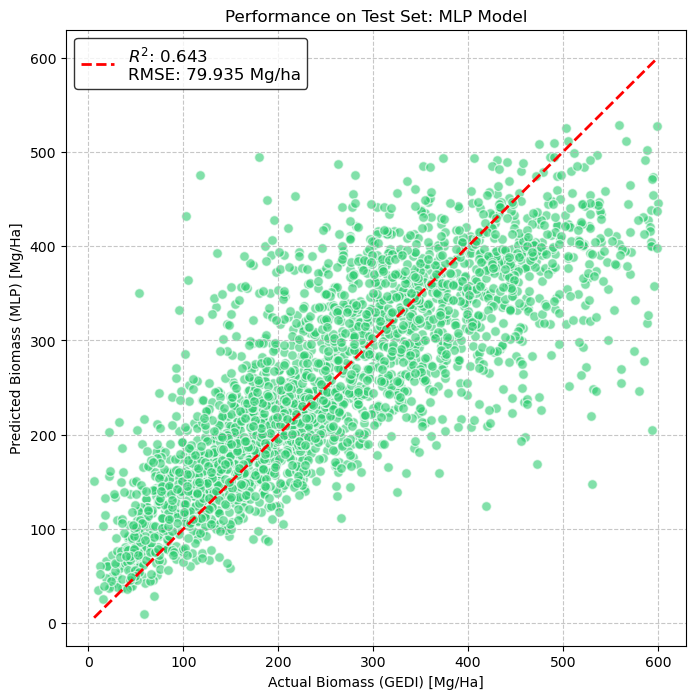

In [10]:
#visualization
import matplotlib.pyplot as plt

# RMSE and R2
rmse_val = 79.935
r2_val = 0.643

# Create text for the legend (using LaTeX for R squared)
# \n is used to create a new line to keep the legend box tidy
stats_label = f"$R^2$: {r2_val:.3f}\nRMSE: {rmse_val:.3f} Mg/ha"

plt.figure(figsize=(8, 8))
plt.scatter(y_true_test, y_pred_test, alpha=0.6, color='#2ecc71', edgecolor='white', s=50)
# Diagonal line 1:1
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', lw=2, label=stats_label)
plt.legend(loc='upper left', fontsize=12, frameon=True, edgecolor='black')
plt.xlabel('Actual Biomass (GEDI) [Mg/Ha]')
plt.ylabel('Predicted Biomass (MLP) [Mg/Ha]')
plt.title('Performance on Test Set: MLP Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Inference Model

In [11]:
#preaper dataset for infrance
df_dataset= df_dataset.drop('gedi', axis = 1)

#Device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)
best_model.eval()

# Perform Scaling on Feature (X)
# Using scaler_x which has been "learned" during the training
X_infer_scaled = data_model.scaler_x.transform(df_dataset)

# Convert to Tensor and Perform Prediction
# We do this in no_grad mode to save memory
X_tensor = torch.tensor(X_infer_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_scaled = best_model(X_tensor)
    # Move the results to the CPU and convert to NumPy
    y_pred_scaled = y_pred_scaled.cpu().numpy()

# Inverse Transform Prediction Result (y)
# Returns small numbers (-1 to 1) to their original units of Mg/Ha
y_pred_real = data_model.scaler_y.inverse_transform(y_pred_scaled)

# Insert Prediction Results Back into DataFrame
df_dataset['biomass_pred'] = y_pred_real.flatten()

print("Inference complete! Prediction values ​​have been entered into the 'biomass_pred' column.")

Inference complete! Prediction values ​​have been entered into the 'biomass_pred' column.


c:\Users\LENOVO\.conda\envs\geoAI\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25652\1245190131.py:7: SyntaxWarning: invalid escape sequence '\P'
  path_shp = 'D:\Project\Forest Biomass\shp\sulsel\sulsel.shp'


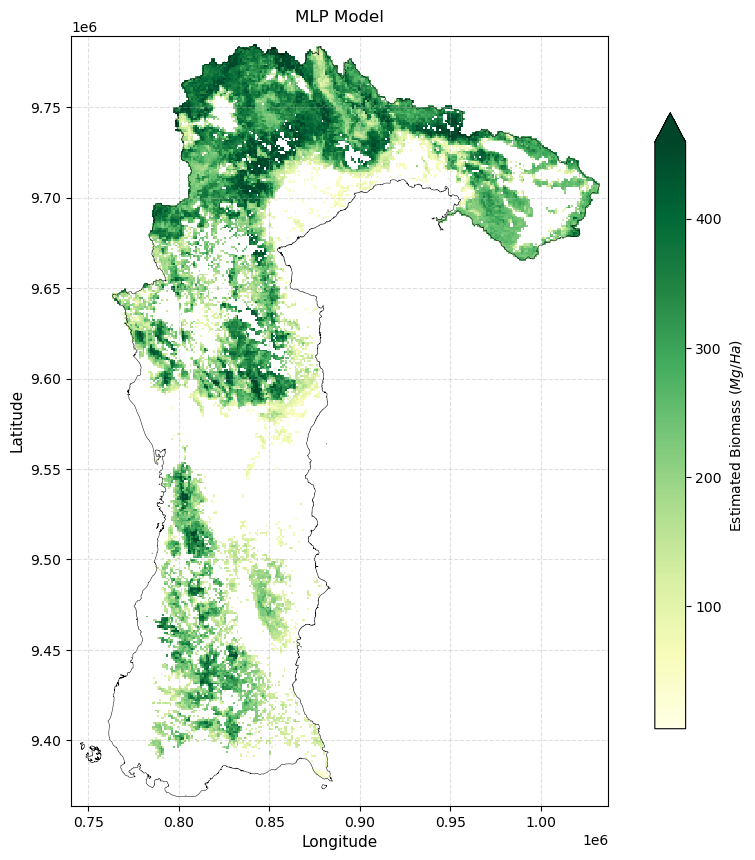

In [13]:
import geopandas as gpd

#visualizatiom
data_inference = df_dataset.to_xarray().sortby('x').sortby('y')

#load shapefile
path_shp = 'D:\Project\Forest Biomass\shp\sulsel\sulsel.shp' 
gdf_sulsel = gpd.read_file(path_shp)
gdf_sulsel = gdf_sulsel.to_crs(epsg=32750)

plt.figure(figsize=(12, 10))
ax = plt.gca() # Mengambil axes yang aktif

# Plotting data from xarray
# robust=True is very helpful so that color contrast is not damaged by GEDI outliers
plot = data_inference['biomass_pred'].plot(
    ax=ax,
    cmap='YlGn', 
    robust=True,
    vmin = 5,
    cbar_kwargs={'label': 'Estimated Biomass ($Mg/Ha$)', 'shrink': 0.8}
)

#plot shp
gdf_sulsel.plot(
    ax=ax, 
    color='none', 
    edgecolor='black', 
    linewidth=0.35, 
    label='Batas Administrasi'
)

# Get the coordinate limits from SHP (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = gdf_sulsel.total_bounds

# Provides a little "padding"
padding = 5000 
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

# 'equal' ensures that 1 degree Lat = 1 degree Lon in the visual display
# adjustable='box' ensures that the box plot remains neat even when the aspect is locked
ax.set_aspect('equal', adjustable='box')

plt.title('MLP Model', fontsize=12, pad=10)
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

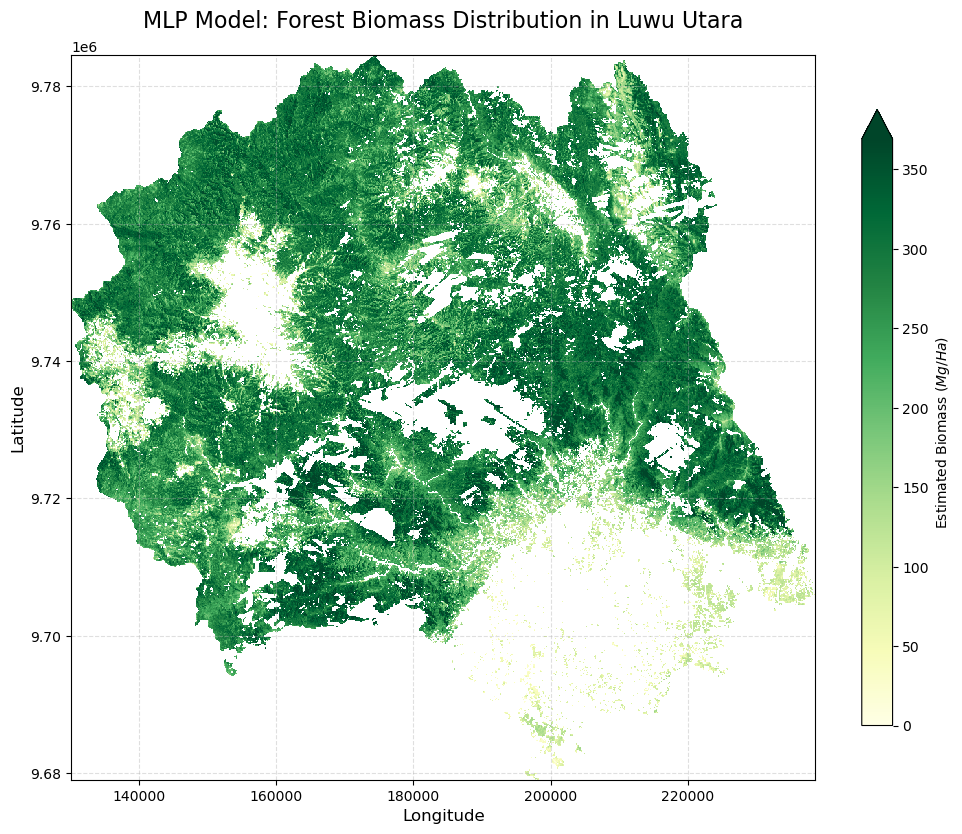

In [37]:
import matplotlib.pyplot as plt

#to xarray
data_inference = df_dataset.to_xarray().sortby('x').sortby('y')

#Prepare the figure
plt.figure(figsize=(12, 10))
ax = plt.gca() # Take active axes

# Plotting data from xarray
# robust=True is very helpful so that color contrast is not damaged by GEDI outliers
plot = data_inference['biomass_pred'].plot(
    ax=ax,
    cmap='YlGn', 
    robust=True,
    vmin = 0,
    cbar_kwargs={'label': 'Estimated Biomass ($Mg/Ha$)', 'shrink': 0.8}
)

# 'equal' ensures that 1 degree Lat = 1 degree Lon in the visual display
# adjustable='box' ensures that the box plot remains neat even when the aspect is locked
ax.set_aspect('equal', adjustable='box')

plt.title('MLP Model: Forest Biomass Distribution in Luwu Utara', fontsize=16, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

#### Save to Geotif

In [ ]:
ds_save = data_inference['biomass_pred']
save_data = ds_save.rio.write_crs('EPSG:32750')
save_data.rio.to_raster('biomass_predic_mlp.tif')